# BeetleCast 03 — Temporal AlphaEarth ablation

This notebook tests whether the **full pre-label AEF history** improves on the existing single-year AEF model.

It compares:

1. Sentinel-2 baseline
2. Sentinel-2 + latest pre-label AEF
3. Sentinel-2 + temporal AEF history

Leakage-safe AEF windows:

- 2022 labels use AEF 2018–2021
- 2023 labels use AEF 2018–2022
- AEF 2023–2025 is ignored during retrospective validation

Temporal AEF features:

- latest pre-label embedding
- historical mean
- historical standard deviation
- recent one-year change
- long-term change from earliest available year


In [5]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import rasterio
import rioxarray

from affine import Affine
from pyproj import CRS
from rasterio.enums import Resampling
from rasterio.vrt import WarpedVRT
from rasterio.transform import from_origin

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
PATCH_PIXELS = 5
TEST_FRACTION = 0.25
MIN_AEF_YEAR = 2018

cwd = Path.cwd()
if (cwd / "hackathon_data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "hackathon_data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not find hackathon_data/. Launch Jupyter from project_root."
    )

DATA_ROOT = PROJECT_ROOT / "hackathon_data"
RAW_ROOT = DATA_ROOT / "raw"
BASELINE_ROOT = PROJECT_ROOT / "outputs" / "baseline"
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "temporal_aef"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_ROOT:", OUTPUT_ROOT)


PROJECT_ROOT: /Users/hemat/Desktop/hackathon-demo
OUTPUT_ROOT: /Users/hemat/Desktop/hackathon-demo/outputs/temporal_aef


## 1. Load the baseline training table

In [6]:
training_path = BASELINE_ROOT / "beetlecast_training_table.csv"
assert training_path.exists(), (
    "Missing outputs/baseline/beetlecast_training_table.csv. "
    "Run notebook 01 first."
)

training = pd.read_csv(training_path)

baseline_features = [
    "ndvi_recent",
    "ndre_recent",
    "nbr_recent",
    "ndvi_prior",
    "ndre_prior",
    "nbr_prior",
    "ndvi_change",
    "ndre_change",
    "nbr_change",
    "ndvi_std",
    "ndre_std",
    "valid_fraction",
]

required = {
    "label_year",
    "patch_row",
    "patch_col",
    "target",
    "spatial_block",
} | set(baseline_features)

missing = required - set(training.columns)
assert not missing, f"Missing baseline columns: {missing}"

print("Training rows:", len(training))
print(training.groupby(["label_year", "target"]).size())


Training rows: 19944
label_year  target
2022        0         7602
            1         2534
2023        0         7356
            1         2452
dtype: int64


## 2. Discover all annual AEF TIFFs

In [7]:
aef_tifs = [
    p for p in RAW_ROOT.rglob("*.tif")
    if (
        "aef" in str(p).lower()
        or "alphaearth" in str(p).lower()
        or "embedding" in str(p).lower()
    )
]

assert aef_tifs, (
    "No AEF TIFFs found under hackathon_data/raw/. "
    "Put them in hackathon_data/raw/aef_embeddings/."
)

def infer_year(path):
    match = re.search(r"(20(?:1[7-9]|2[0-5]))", path.name)
    return int(match.group(1)) if match else None

aef_by_year = {}
for path in aef_tifs:
    year = infer_year(path)
    if year is not None:
        aef_by_year.setdefault(year, []).append(path)

print("AEF years found:", sorted(aef_by_year))

required_years = set(range(2018, 2023))
missing_years = sorted(required_years - set(aef_by_year))
assert not missing_years, (
    f"Missing AEF years required for this experiment: {missing_years}"
)

selected_aef = {
    year: sorted(aef_by_year[year])[0]
    for year in sorted(aef_by_year)
    if 2018 <= year <= 2022
}

for year, path in selected_aef.items():
    print(year, "->", path)


AEF years found: [2018, 2019, 2020, 2021, 2022, 2024, 2025]
2018 -> /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/aef_embeddings/aef_F3_Germany_BarkBeetle_2018.tif
2019 -> /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/aef_embeddings/aef_F3_Germany_BarkBeetle_2019.tif
2020 -> /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/aef_embeddings/aef_F3_Germany_BarkBeetle_2020.tif
2021 -> /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/aef_embeddings/aef_F3_Germany_BarkBeetle_2021.tif
2022 -> /Users/hemat/Desktop/hackathon-demo/hackathon_data/raw/aef_embeddings/aef_F3_Germany_BarkBeetle_2022.tif


## 3. Reconstruct the modelling patch grid

In [8]:
zarr_paths = list(RAW_ROOT.rglob("cube.zarr"))
f3_zarr = [
    p for p in zarr_paths
    if "f3" in str(p).lower()
    or "bark" in str(p).lower()
    or "germany" in str(p).lower()
]
assert f3_zarr or zarr_paths, "No Sentinel-2 cube found"
CUBE_PATH = (f3_zarr or zarr_paths)[0]

ds = xr.open_zarr(CUBE_PATH, chunks="auto")

if float(ds.y.values[0]) < float(ds.y.values[-1]):
    ds = ds.sortby("y", ascending=False)

x = np.asarray(ds.x.values)
y = np.asarray(ds.y.values)

dx = float(abs(x[1] - x[0]))
dy = float(abs(y[1] - y[0]))

left = float(x.min() - dx / 2)
top = float(y.max() + dy / 2)

base_transform = from_origin(left, top, dx, dy)
patch_transform = base_transform * Affine.scale(PATCH_PIXELS, PATCH_PIXELS)

patch_height = ds.sizes["y"] // PATCH_PIXELS
patch_width = ds.sizes["x"] // PATCH_PIXELS

def infer_cube_crs(dataset):
    try:
        if dataset.rio.crs is not None:
            return CRS.from_user_input(dataset.rio.crs)
    except Exception:
        pass

    if "spatial_ref" in dataset:
        attrs = dataset["spatial_ref"].attrs
        for key in ("crs_wkt", "spatial_ref", "wkt"):
            value = attrs.get(key)
            if value:
                return CRS.from_user_input(value)

    raise ValueError("Could not infer Sentinel-2 CRS")

grid_crs = infer_cube_crs(ds)

print("Patch grid:", patch_height, "x", patch_width)
print("CRS:", grid_crs)


Patch grid: 252 x 213
CRS: PROJCS["WGS 84 / UTM zone 32N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",9],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32632"]]


## 4. Align every AEF year to the patch grid

In [9]:
def read_aef_on_patch_grid(path):
    with rasterio.open(path) as src:
        print(
            f"{path.name}: bands={src.count}, CRS={src.crs}, "
            f"shape={src.height}x{src.width}"
        )

        with WarpedVRT(
            src,
            crs=grid_crs,
            transform=patch_transform,
            width=patch_width,
            height=patch_height,
            resampling=Resampling.bilinear,
            nodata=np.nan,
        ) as vrt:
            data = vrt.read(masked=True).filled(np.nan).astype("float32")

    return data

aef_arrays = {
    year: read_aef_on_patch_grid(path)
    for year, path in selected_aef.items()
}

band_counts = {year: arr.shape[0] for year, arr in aef_arrays.items()}
assert len(set(band_counts.values())) == 1, (
    f"AEF band counts differ by year: {band_counts}"
)

N_AEF_BANDS = next(iter(band_counts.values()))
print("AEF bands per year:", N_AEF_BANDS)


aef_F3_Germany_BarkBeetle_2018.tif: bands=64, CRS=EPSG:32632, shape=1297x1098
aef_F3_Germany_BarkBeetle_2019.tif: bands=64, CRS=EPSG:32632, shape=1297x1098
aef_F3_Germany_BarkBeetle_2020.tif: bands=64, CRS=EPSG:32632, shape=1297x1098
aef_F3_Germany_BarkBeetle_2021.tif: bands=64, CRS=EPSG:32632, shape=1297x1098
aef_F3_Germany_BarkBeetle_2022.tif: bands=64, CRS=EPSG:32632, shape=1297x1098
AEF bands per year: 64


## 5. Build leakage-safe temporal AEF features

In [10]:
feature_rows = []

for row in training.itertuples(index=False):
    label_year = int(row.label_year)
    latest_year = label_year - 1

    valid_years = [
        year for year in sorted(aef_arrays)
        if MIN_AEF_YEAR <= year <= latest_year
    ]

    if len(valid_years) < 2:
        raise ValueError(
            f"Not enough pre-label AEF history for label year {label_year}"
        )

    r = int(row.patch_row)
    c = int(row.patch_col)

    stack = np.stack(
        [aef_arrays[year][:, r, c] for year in valid_years],
        axis=0,
    )

    latest = stack[-1]
    history_mean = np.nanmean(stack, axis=0)
    history_std = np.nanstd(stack, axis=0)
    recent_change = stack[-1] - stack[-2]
    long_change = stack[-1] - stack[0]

    values = {}
    for i in range(N_AEF_BANDS):
        band = i + 1
        values[f"aef_latest_{band:02d}"] = latest[i]
        values[f"aef_mean_{band:02d}"] = history_mean[i]
        values[f"aef_std_{band:02d}"] = history_std[i]
        values[f"aef_recent_change_{band:02d}"] = recent_change[i]
        values[f"aef_long_change_{band:02d}"] = long_change[i]

    feature_rows.append(values)

temporal_aef = pd.DataFrame(feature_rows)
combined = pd.concat(
    [training.reset_index(drop=True), temporal_aef],
    axis=1,
)

latest_features = [
    col for col in temporal_aef.columns
    if col.startswith("aef_latest_")
]

temporal_features = list(temporal_aef.columns)

print("Latest AEF features:", len(latest_features))
print("All temporal AEF features:", len(temporal_features))
print("Combined shape:", combined.shape)

combined_path = OUTPUT_ROOT / "beetlecast_temporal_aef_training_table.csv"
combined.to_csv(combined_path, index=False)

print("Saved:", combined_path)


Latest AEF features: 64
All temporal AEF features: 320
Combined shape: (19944, 338)
Saved: /Users/hemat/Desktop/hackathon-demo/outputs/temporal_aef/beetlecast_temporal_aef_training_table.csv


## 6. Build one common blocked split

In [11]:
all_required_features = baseline_features + temporal_features

usable = combined.dropna(
    subset=all_required_features + ["spatial_block", "target"]
).copy()

print("Rows retained after requiring complete temporal AEF:", len(usable))

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_FRACTION,
    random_state=RANDOM_STATE,
)

train_idx, test_idx = next(
    splitter.split(
        usable,
        usable["target"],
        usable["spatial_block"],
    )
)

train = usable.iloc[train_idx]
test = usable.iloc[test_idx]

print("Train rows:", len(train))
print("Test rows:", len(test))
print("Train blocks:", train["spatial_block"].nunique())
print("Test blocks:", test["spatial_block"].nunique())
print("Train positive rate:", train["target"].mean())
print("Test positive rate:", test["target"].mean())


Rows retained after requiring complete temporal AEF: 19944
Train rows: 14741
Test rows: 5203
Train blocks: 474
Test blocks: 158
Train positive rate: 0.23207380774709993
Test positive rate: 0.30078800691908514


## 7. Train the three-model ablation

In [12]:
def top_fraction_capture(y_true, risk, fraction=0.10):
    y_true = np.asarray(y_true).astype(int)
    risk = np.asarray(risk)

    n_select = max(1, int(np.ceil(len(risk) * fraction)))
    selected = np.argsort(risk)[-n_select:]

    total_positive = y_true.sum()
    if total_positive == 0:
        return np.nan

    return y_true[selected].sum() / total_positive

def fit_and_score(feature_columns, name):
    model = HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=350,
        max_leaf_nodes=31,
        min_samples_leaf=25,
        l2_regularization=2.0,
        random_state=RANDOM_STATE,
    )

    weights = compute_sample_weight(
        class_weight="balanced",
        y=train["target"].astype(int),
    )

    model.fit(
        train[feature_columns],
        train["target"].astype(int),
        sample_weight=weights,
    )

    risk = model.predict_proba(test[feature_columns])[:, 1]
    y_true = test["target"].to_numpy().astype(int)

    metrics = {
        "model": name,
        "feature_count": len(feature_columns),
        "pr_auc": average_precision_score(y_true, risk),
        "roc_auc": roc_auc_score(y_true, risk),
        "top_10_percent_capture": top_fraction_capture(
            y_true, risk, fraction=0.10
        ),
    }

    return model, risk, metrics

baseline_model, baseline_risk, baseline_metrics = fit_and_score(
    baseline_features,
    "Sentinel-2 baseline",
)

latest_model, latest_risk, latest_metrics = fit_and_score(
    baseline_features + latest_features,
    "Sentinel-2 + latest AEF",
)

temporal_model, temporal_risk, temporal_metrics = fit_and_score(
    baseline_features + temporal_features,
    "Sentinel-2 + temporal AEF",
)

metrics_df = pd.DataFrame([
    baseline_metrics,
    latest_metrics,
    temporal_metrics,
])

metrics_path = OUTPUT_ROOT / "beetlecast_temporal_aef_comparison.csv"
metrics_df.to_csv(metrics_path, index=False)

display(metrics_df)
print("Saved:", metrics_path)


,model,feature_count,pr_auc,roc_auc,top_10_percent_capture
0,Sentinel-2 baseline,12,0.706418,0.822893,0.292013
1,Sentinel-2 + latest AEF,76,0.889624,0.935822,0.325240
2,Sentinel-2 + temporal AEF,332,0.929398,0.962870,0.330351


Saved: /Users/hemat/Desktop/hackathon-demo/outputs/temporal_aef/beetlecast_temporal_aef_comparison.csv


## 8. Plot the result

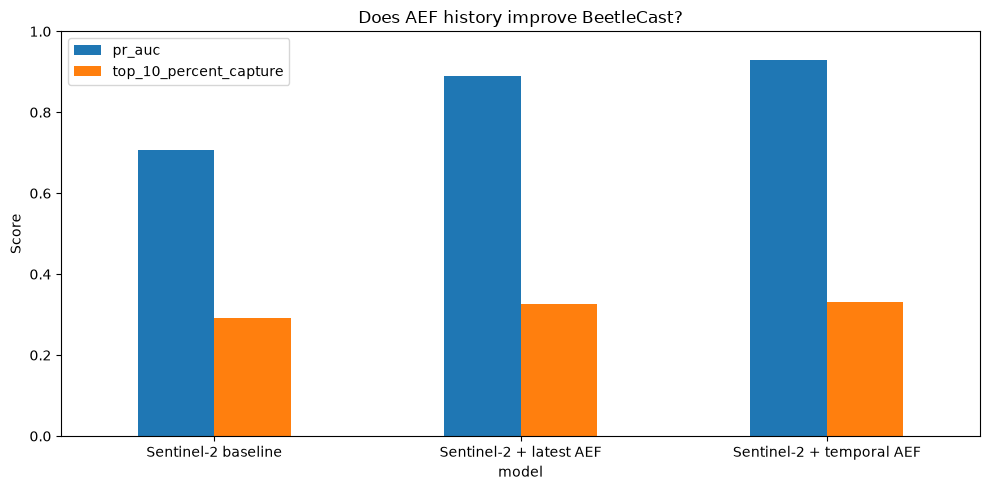

Saved: /Users/hemat/Desktop/hackathon-demo/outputs/temporal_aef/beetlecast_temporal_aef_comparison.png


In [13]:
plot_df = metrics_df.set_index("model")[
    ["pr_auc", "top_10_percent_capture"]
]

ax = plot_df.plot(kind="bar", figsize=(10, 5), rot=0)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Does AEF history improve BeetleCast?")
plt.tight_layout()

plot_path = OUTPUT_ROOT / "beetlecast_temporal_aef_comparison.png"
plt.savefig(plot_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", plot_path)


## 9. Final decision

In [14]:
best_idx = metrics_df["pr_auc"].idxmax()
best = metrics_df.loc[best_idx]

print("TEMPORAL AEF COMPARISON COMPLETE")
print("--------------------------------")
for row in metrics_df.itertuples(index=False):
    print(
        f"{row.model}: "
        f"PR-AUC={row.pr_auc:.3f}, "
        f"ROC-AUC={row.roc_auc:.3f}, "
        f"Top-10% capture={row.top_10_percent_capture:.1%}"
    )

print()
print("Best PR-AUC model:", best["model"])

latest_row = metrics_df[
    metrics_df["model"] == "Sentinel-2 + latest AEF"
].iloc[0]
temporal_row = metrics_df[
    metrics_df["model"] == "Sentinel-2 + temporal AEF"
].iloc[0]

if (
    temporal_row["pr_auc"] > latest_row["pr_auc"]
    or temporal_row["top_10_percent_capture"]
    > latest_row["top_10_percent_capture"]
):
    print(
        "Decision: keep temporal AEF history in the competition model."
    )
else:
    print(
        "Decision: keep the simpler latest-year AEF model. "
        "The full history did not improve the blocked test."
    )


TEMPORAL AEF COMPARISON COMPLETE
--------------------------------
Sentinel-2 baseline: PR-AUC=0.706, ROC-AUC=0.823, Top-10% capture=29.2%
Sentinel-2 + latest AEF: PR-AUC=0.890, ROC-AUC=0.936, Top-10% capture=32.5%
Sentinel-2 + temporal AEF: PR-AUC=0.929, ROC-AUC=0.963, Top-10% capture=33.0%

Best PR-AUC model: Sentinel-2 + temporal AEF
Decision: keep temporal AEF history in the competition model.
